In [1]:
import pandas as pd
import numpy as np
#https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

In [2]:
# Lendo o dataframe
df = pd.read_csv("../0. Dados/dados_voo.csv")
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0,2013-01-01


- year,month,day: Date of departure
- dep_time,arr_time: Departure and arrival times, format HMM or HHMM
- dep_delay,arr_delay: Departure and arrival delays, in minutes. Negative times represent early departures/arrivals.
- hour,minute : Time of departure broken in to hour and minutes
- carrier: Two letter carrier abbreviation
- tailnum: Plane tail number
- flight: Flight number
- origin,dest: Origin and destination.
- air_time: Amount of time spent in the air
- distance: Distance flown

In [3]:
type(df)

pandas.core.frame.DataFrame

### Explorando as características do dataframe

In [4]:
# Formato do dataframe
df.shape

(336776, 17)

In [5]:
# Nome das colunas
df.columns

Index(['year', 'month', 'day', 'dep_time', 'dep_delay', 'arr_time',
       'arr_delay', 'carrier', 'tailnum', 'flight', 'origin', 'dest',
       'air_time', 'distance', 'hour', 'minute', 'data'],
      dtype='object')

In [6]:
# Tipo das variáveis
df.dtypes

year           int64
month          int64
day            int64
dep_time     float64
dep_delay    float64
arr_time     float64
arr_delay    float64
carrier       object
tailnum       object
flight         int64
origin        object
dest          object
air_time     float64
distance       int64
hour         float64
minute       float64
data          object
dtype: object

In [7]:
# Informações sobre preenchimento e nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   year       336776 non-null  int64  
 1   month      336776 non-null  int64  
 2   day        336776 non-null  int64  
 3   dep_time   328521 non-null  float64
 4   dep_delay  328521 non-null  float64
 5   arr_time   328063 non-null  float64
 6   arr_delay  327346 non-null  float64
 7   carrier    336776 non-null  object 
 8   tailnum    334264 non-null  object 
 9   flight     336776 non-null  int64  
 10  origin     336776 non-null  object 
 11  dest       336776 non-null  object 
 12  air_time   327346 non-null  float64
 13  distance   336776 non-null  int64  
 14  hour       328521 non-null  float64
 15  minute     328521 non-null  float64
 16  data       336776 non-null  object 
dtypes: float64(7), int64(5), object(5)
memory usage: 43.7+ MB


In [8]:
# Quantidade e descrição de elementos únicos
print(df["year"].unique())
print(df["year"].nunique())

[2013]
1


In [9]:
# selecionar colunas com base no tipo
print(list(df.select_dtypes(include="object")))

['carrier', 'tailnum', 'origin', 'dest', 'data']


In [10]:
#  lista está correta? O python pode interpretar errado? 
df["flight"] = df["flight"].astype("str")
print(list(df.select_dtypes(include="object")))

['carrier', 'tailnum', 'flight', 'origin', 'dest', 'data']


In [11]:
for col in list(df.select_dtypes(include="object")) + ["year", "month"]:
    print(f"{col}: {df[col].nunique()} - {df[col].unique()}")

carrier: 16 - ['UA' 'AA' 'B6' 'DL' 'EV' 'MQ' 'US' 'WN' 'VX' 'FL' 'AS' '9E' 'F9' 'HA'
 'YV' 'OO']
tailnum: 4043 - ['N14228' 'N24211' 'N619AA' ... 'N776SK' 'N785SK' 'N557AS']
flight: 3844 - ['1545' '1714' '1141' ... '3583' '3857' '3539']
origin: 3 - ['EWR' 'LGA' 'JFK']
dest: 105 - ['IAH' 'MIA' 'BQN' 'ATL' 'ORD' 'FLL' 'IAD' 'MCO' 'PBI' 'TPA' 'LAX' 'SFO'
 'DFW' 'BOS' 'LAS' 'MSP' 'DTW' 'RSW' 'SJU' 'PHX' 'BWI' 'CLT' 'BUF' 'DEN'
 'SNA' 'MSY' 'SLC' 'XNA' 'MKE' 'SEA' 'ROC' 'SYR' 'SRQ' 'RDU' 'CMH' 'JAX'
 'CHS' 'MEM' 'PIT' 'SAN' 'DCA' 'CLE' 'STL' 'MYR' 'JAC' 'MDW' 'HNL' 'BNA'
 'AUS' 'BTV' 'PHL' 'STT' 'EGE' 'AVL' 'PWM' 'IND' 'SAV' 'CAK' 'HOU' 'LGB'
 'DAY' 'ALB' 'BDL' 'MHT' 'MSN' 'GSO' 'CVG' 'BUR' 'RIC' 'GSP' 'GRR' 'MCI'
 'ORF' 'SAT' 'SDF' 'PDX' 'SJC' 'OMA' 'CRW' 'OAK' 'SMF' 'TUL' 'TYS' 'OKC'
 'PVD' 'DSM' 'PSE' 'BHM' 'CAE' 'HDN' 'BZN' 'MTJ' 'EYW' 'PSP' 'ACK' 'BGR'
 'ABQ' 'ILM' 'MVY' 'SBN' 'LEX' 'CHO' 'TVC' 'ANC' 'LGA']
data: 365 - ['2013-01-01' '2013-01-02' '2013-01-03' '2013-01-04' '2013-01-05'
 '

### Slice & Filtros
Quando o objetivo é selecionar uma parte do dataframe através de colunas ou linhas, sem nenhum tipo de condicional diremos ser uma operação de *slice*, caso contrário de *filtro*
As formas mais recomendadas para este cenário são o loc e iloc
- loc() → labels das linhas e colunas
- iloc() → index das linhas e colunas

Slices

In [12]:
df.loc[:, "distance"]

0         1400
1         1416
2         1089
3         1576
4          762
          ... 
336771     213
336772     198
336773     764
336774     419
336775     431
Name: distance, Length: 336776, dtype: int64

In [13]:
df.loc[1]

year               2013
month                 1
day                   1
dep_time          533.0
dep_delay           4.0
arr_time          850.0
arr_delay          20.0
carrier              UA
tailnum          N24211
flight             1714
origin              LGA
dest                IAH
air_time          227.0
distance           1416
hour                5.0
minute             33.0
data         2013-01-01
Name: 1, dtype: object

In [14]:
df.iloc[0]

year               2013
month                 1
day                   1
dep_time          517.0
dep_delay           2.0
arr_time          830.0
arr_delay          11.0
carrier              UA
tailnum          N14228
flight             1545
origin              EWR
dest                IAH
air_time          227.0
distance           1400
hour                5.0
minute             17.0
data         2013-01-01
Name: 0, dtype: object

In [15]:
df.iloc[:, [1,3,6]]

,month,dep_time,arr_delay
0,1,517.0,11.0
1,1,533.0,20.0
2,1,542.0,33.0
3,1,544.0,-18.0
4,1,554.0,-25.0
...,...,...,...
336771,9,NaN,NaN
336772,9,NaN,NaN
336773,9,NaN,NaN
336774,9,NaN,NaN


Filtros

In [16]:
# condicionais com loc
df.loc[df["origin"]== "JFK"]

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01
8,2013,1,1,557.0,-3.0,838.0,-8.0,B6,N593JB,79,JFK,MCO,140.0,944,5.0,57.0,2013-01-01
10,2013,1,1,558.0,-2.0,849.0,-2.0,B6,N793JB,49,JFK,PBI,149.0,1028,5.0,58.0,2013-01-01
11,2013,1,1,558.0,-2.0,853.0,-3.0,B6,N657JB,71,JFK,TPA,158.0,1005,5.0,58.0,2013-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336766,2013,9,30,2240.0,-10.0,2347.0,-20.0,B6,N281JB,2002,JFK,BUF,52.0,301,22.0,40.0,2013-09-30
336767,2013,9,30,2241.0,-5.0,2345.0,-16.0,B6,N346JB,486,JFK,ROC,47.0,264,22.0,41.0,2013-09-30
336768,2013,9,30,2307.0,12.0,2359.0,1.0,B6,N565JB,718,JFK,BOS,33.0,187,23.0,7.0,2013-09-30
336769,2013,9,30,2349.0,-10.0,325.0,-25.0,B6,N516JB,745,JFK,PSE,196.0,1617,23.0,49.0,2013-09-30


In [17]:
# condicionais sem loc
df[df["origin"]== "JFK"]

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01
8,2013,1,1,557.0,-3.0,838.0,-8.0,B6,N593JB,79,JFK,MCO,140.0,944,5.0,57.0,2013-01-01
10,2013,1,1,558.0,-2.0,849.0,-2.0,B6,N793JB,49,JFK,PBI,149.0,1028,5.0,58.0,2013-01-01
11,2013,1,1,558.0,-2.0,853.0,-3.0,B6,N657JB,71,JFK,TPA,158.0,1005,5.0,58.0,2013-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336766,2013,9,30,2240.0,-10.0,2347.0,-20.0,B6,N281JB,2002,JFK,BUF,52.0,301,22.0,40.0,2013-09-30
336767,2013,9,30,2241.0,-5.0,2345.0,-16.0,B6,N346JB,486,JFK,ROC,47.0,264,22.0,41.0,2013-09-30
336768,2013,9,30,2307.0,12.0,2359.0,1.0,B6,N565JB,718,JFK,BOS,33.0,187,23.0,7.0,2013-09-30
336769,2013,9,30,2349.0,-10.0,325.0,-25.0,B6,N516JB,745,JFK,PSE,196.0,1617,23.0,49.0,2013-09-30


In [18]:
# múltiplas condicionais
df.loc[(df["origin"]== "JFK") & (df["carrier"]== "B6")]

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01
8,2013,1,1,557.0,-3.0,838.0,-8.0,B6,N593JB,79,JFK,MCO,140.0,944,5.0,57.0,2013-01-01
10,2013,1,1,558.0,-2.0,849.0,-2.0,B6,N793JB,49,JFK,PBI,149.0,1028,5.0,58.0,2013-01-01
11,2013,1,1,558.0,-2.0,853.0,-3.0,B6,N657JB,71,JFK,TPA,158.0,1005,5.0,58.0,2013-01-01
15,2013,1,1,559.0,0.0,702.0,-4.0,B6,N708JB,1806,JFK,BOS,44.0,187,5.0,59.0,2013-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336765,2013,9,30,2240.0,-5.0,2334.0,-17.0,B6,N354JB,1816,JFK,SYR,41.0,209,22.0,40.0,2013-09-30
336766,2013,9,30,2240.0,-10.0,2347.0,-20.0,B6,N281JB,2002,JFK,BUF,52.0,301,22.0,40.0,2013-09-30
336767,2013,9,30,2241.0,-5.0,2345.0,-16.0,B6,N346JB,486,JFK,ROC,47.0,264,22.0,41.0,2013-09-30
336768,2013,9,30,2307.0,12.0,2359.0,1.0,B6,N565JB,718,JFK,BOS,33.0,187,23.0,7.0,2013-09-30


In [19]:
# condicionais com iloc
df.loc[df["day"]==1].iloc[:,2:]

,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
0,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01
1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01
2,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01
3,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01
4,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0,2013-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309915,1,2302.0,-3.0,8.0,-5.0,B6,N629JB,718,JFK,BOS,42.0,187,23.0,2.0,2013-09-01
309916,1,2329.0,44.0,40.0,39.0,B6,N373JB,234,JFK,BTV,48.0,266,23.0,29.0,2013-09-01
309917,1,2351.0,-8.0,335.0,-15.0,B6,N588JB,745,JFK,PSE,204.0,1617,23.0,51.0,2013-09-01
309918,1,2352.0,-7.0,323.0,-21.0,B6,N768JB,1503,JFK,SJU,196.0,1598,23.0,52.0,2013-09-01


In [20]:
# where
df.where(df["distance"]>1000)

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
0,2013.0,1.0,1.0,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400.0,5.0,17.0,2013-01-01
1,2013.0,1.0,1.0,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416.0,5.0,33.0,2013-01-01
2,2013.0,1.0,1.0,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089.0,5.0,42.0,2013-01-01
3,2013.0,1.0,1.0,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576.0,5.0,44.0,2013-01-01
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
#np where
np.where(df["distance"]>1000)

(array([     0,      1,      2, ..., 336754, 336762, 336769],
       shape=(147105,)),)

In [ ]:
df[df["origin"].isin(["JKF", "EWR"])]
# df[~df["origin"].isin(["JKF", "EWR"])]

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01
5,2013,1,1,554.0,-4.0,740.0,12.0,UA,N39463,1696,EWR,ORD,150.0,719,5.0,54.0,2013-01-01
6,2013,1,1,555.0,-5.0,913.0,19.0,B6,N516JB,507,EWR,FLL,158.0,1065,5.0,55.0,2013-01-01
13,2013,1,1,558.0,-2.0,923.0,-14.0,UA,N53441,1124,EWR,SFO,361.0,2565,5.0,58.0,2013-01-01
16,2013,1,1,559.0,-1.0,854.0,-8.0,UA,N76515,1187,EWR,LAS,337.0,2227,5.0,59.0,2013-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336752,2013,9,30,2142.0,13.0,2250.0,11.0,EV,N12957,4509,EWR,PWM,47.0,284,21.0,42.0,2013-09-30
336755,2013,9,30,2149.0,-7.0,2245.0,-23.0,UA,N813UA,523,EWR,BOS,37.0,200,21.0,49.0,2013-09-30
336756,2013,9,30,2150.0,-9.0,2250.0,-16.0,EV,N10575,3842,EWR,MHT,39.0,209,21.0,50.0,2013-09-30
336760,2013,9,30,2211.0,72.0,2339.0,57.0,EV,N12145,4672,EWR,STL,120.0,872,22.0,11.0,2013-09-30


### Operações

Operações em colunas **sem** condicionais de observação (linha)

In [25]:
df["air_time"]/60

0         3.783333
1         3.783333
2         2.666667
3         3.050000
4         1.933333
            ...   
336771         NaN
336772         NaN
336773         NaN
336774         NaN
336775         NaN
Name: air_time, Length: 336776, dtype: float64

In [27]:
df["rota"] = df["origin"] + "-" + df["dest"]
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data,rota
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01,EWR-IAH
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01,LGA-IAH
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01,JFK-MIA
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01,JFK-BQN
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0,2013-01-01,LGA-ATL


In [28]:
df["rota"].nunique()

224

In [29]:
print(
    df["arr_delay"].max(),
    df["arr_delay"].min(),
    df["arr_delay"].mean()
)

1272.0 -86.0 6.89537675731489


In [30]:
df.describe()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,air_time,distance,hour,minute
count,336776.0,336776.000000,336776.000000,328521.000000,328521.000000,328063.000000,327346.000000,327346.000000,336776.000000,328521.000000,328521.000000
mean,2013.0,6.548510,15.710787,1349.109947,12.639070,1502.054999,6.895377,150.686460,1039.912604,13.173544,31.755501
std,0.0,3.414457,8.768607,488.281791,40.210061,533.264132,44.633292,93.688305,733.233033,4.894426,18.230997
min,2013.0,1.000000,1.000000,1.000000,-43.000000,1.000000,-86.000000,20.000000,17.000000,0.000000,0.000000
25%,2013.0,4.000000,8.000000,907.000000,-5.000000,1104.000000,-17.000000,82.000000,502.000000,9.000000,16.000000
50%,2013.0,7.000000,16.000000,1401.000000,-2.000000,1535.000000,-5.000000,129.000000,872.000000,14.000000,31.000000
75%,2013.0,10.000000,23.000000,1744.000000,11.000000,1940.000000,14.000000,192.000000,1389.000000,17.000000,49.000000
max,2013.0,12.000000,31.000000,2400.000000,1301.000000,2400.000000,1272.000000,695.000000,4983.000000,24.000000,59.000000


Operações em colunas **com** condicionais de observação (linha)

In [31]:
np.where(df["month"]==1, df["hour"]-4, df["hour"])

array([ 1.,  1.,  1., ..., nan, nan, nan], shape=(336776,))

In [32]:
df.apply(lambda x: x["hour"]-4 if x["month"] == 1 else x["hour"], axis = 1)

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
336771    NaN
336772    NaN
336773    NaN
336774    NaN
336775    NaN
Length: 336776, dtype: float64

In [33]:
df["flg_longe"] = np.where(df["distance"] > 1000, True, False)
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data,rota,flg_longe
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01,EWR-IAH,True
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01,LGA-IAH,True
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01,JFK-MIA,True
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01,JFK-BQN,True
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0,2013-01-01,LGA-ATL,False


In [34]:
df[df["flg_longe"]==True]

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data,rota,flg_longe
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01,EWR-IAH,True
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01,LGA-IAH,True
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01,JFK-MIA,True
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01,JFK-BQN,True
6,2013,1,1,555.0,-5.0,913.0,19.0,B6,N516JB,507,EWR,FLL,158.0,1065,5.0,55.0,2013-01-01,EWR-FLL,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336751,2013,9,30,2140.0,0.0,10.0,-30.0,AA,N335AA,185,JFK,LAX,298.0,2475,21.0,40.0,2013-09-30,JFK-LAX,True
336753,2013,9,30,2145.0,0.0,115.0,-25.0,B6,N633JB,1103,JFK,SJU,192.0,1598,21.0,45.0,2013-09-30,JFK-SJU,True
336754,2013,9,30,2147.0,10.0,30.0,3.0,B6,N627JB,1371,LGA,FLL,139.0,1076,21.0,47.0,2013-09-30,LGA-FLL,True
336762,2013,9,30,2233.0,80.0,112.0,42.0,UA,N578UA,471,EWR,SFO,318.0,2565,22.0,33.0,2013-09-30,EWR-SFO,True


### Agrupando informações

In [36]:
# Média de atrasos por companhia
df.groupby("carrier")["arr_delay"].mean().reset_index()

,carrier,arr_delay
0,9E,7.379669
1,AA,0.364291
2,AS,-9.930889
3,B6,9.457973
4,DL,1.644341
5,EV,15.796431
6,F9,21.920705
7,FL,20.115906
8,HA,-6.915205
9,MQ,10.774733


In [37]:
# Média de tempo vôo por companhia
df.groupby("carrier")["air_time"].mean()

carrier
9E     86.781601
AA    188.822299
AS    325.617772
B6    151.177173
DL    173.688804
EV     90.076192
F9    229.599119
FL    101.143937
HA    623.087719
MQ     91.180253
OO     83.482759
UA    211.791354
US     88.573799
VX    337.002346
WN    147.824809
YV     65.740809
Name: air_time, dtype: float64

In [38]:
# Max de atraso por aeroporto de destino
df.groupby("origin")["dep_delay"].max()

origin
EWR    1126.0
JFK    1301.0
LGA     911.0
Name: dep_delay, dtype: float64

### Reshape data frames

**pivot()**: Reshape através da redefinição de índice e colunas

In [40]:
df_pivot_1 = df.pivot_table(index="origin", columns="dest", values="distance", aggfunc="mean")
df_pivot_1

dest,ABQ,ACK,ALB,ANC,ATL,AUS,AVL,BDL,BGR,BHM,...,SNA,SRQ,STL,STT,SYR,TPA,TUL,TVC,TYS,XNA
origin,,,,,,,,,,,,,,,,,,,,,
EWR,NaN,NaN,143.0,3370.0,746.0,1504.0,583.0,116.0,NaN,NaN,...,2434.0,NaN,872.0,1634.0,195.0,997.0,1215.0,644.0,631.0,1131.0
JFK,1826.0,199.0,NaN,NaN,760.0,1521.0,NaN,NaN,NaN,865.0,...,NaN,1041.0,892.0,1623.0,209.0,1005.0,NaN,NaN,NaN,NaN
LGA,NaN,NaN,NaN,NaN,762.0,NaN,599.0,NaN,378.0,866.0,...,NaN,1047.0,888.0,NaN,198.0,1010.0,NaN,655.0,647.0,1147.0


In [41]:
type(df_pivot_1)

pandas.core.frame.DataFrame

In [42]:
df_pivot_2 = df.pivot_table(index=["origin", "dest"], columns="carrier", values="distance", aggfunc="mean")
df_pivot_2

carrier         9E  AA  AS      B6      DL      EV  F9  FL  HA      MQ  OO  \
origin dest                                                                  
EWR    ALB     NaN NaN NaN     NaN     NaN   143.0 NaN NaN NaN     NaN NaN   
       ANC     NaN NaN NaN     NaN     NaN     NaN NaN NaN NaN     NaN NaN   
       ATL   746.0 NaN NaN     NaN   746.0   746.0 NaN NaN NaN     NaN NaN   
       AUS     NaN NaN NaN     NaN     NaN     NaN NaN NaN NaN     NaN NaN   
       AVL     NaN NaN NaN     NaN     NaN   583.0 NaN NaN NaN     NaN NaN   
...            ...  ..  ..     ...     ...     ...  ..  ..  ..     ...  ..   
LGA    SYR   198.0 NaN NaN     NaN     NaN   198.0 NaN NaN NaN     NaN NaN   
       TPA     NaN NaN NaN  1010.0  1010.0     NaN NaN NaN NaN     NaN NaN   
       TVC     NaN NaN NaN     NaN     NaN   655.0 NaN NaN NaN   655.0 NaN   
       TYS   647.0 NaN NaN     NaN     NaN     NaN NaN NaN NaN     NaN NaN   
       XNA     NaN NaN NaN     NaN     NaN  1147.0 NaN NaN NaN  1147.0 NaN   

carrier          UA  US  VX      WN  YV  
origin dest                              
EWR    ALB      NaN NaN NaN     NaN NaN  
       ANC   3370.0 NaN NaN     NaN NaN  
       ATL    746.0 NaN NaN     NaN NaN  
       AUS   1504.0 NaN NaN  1504.0 NaN  
       AVL      NaN NaN NaN     NaN NaN  
...             ...  ..  ..     ...  ..  
LGA    SYR      NaN NaN NaN     NaN NaN  
       TPA      NaN NaN NaN     NaN NaN  
       TVC      NaN NaN NaN     NaN NaN  
       TYS      NaN NaN NaN     NaN NaN  
       XNA      NaN NaN NaN     NaN NaN  

[224 rows x 16 columns]

In [43]:
df.pivot_table(index="origin", columns="dest", values="distance", aggfunc="count")

dest,ABQ,ACK,ALB,ANC,ATL,AUS,AVL,BDL,BGR,BHM,...,SNA,SRQ,STL,STT,SYR,TPA,TUL,TVC,TYS,XNA
origin,,,,,,,,,,,,,,,,,,,,,
EWR,NaN,NaN,439.0,8.0,5022.0,968.0,265.0,443.0,NaN,NaN,...,825.0,NaN,2516.0,189.0,157.0,2334.0,315.0,24.0,323.0,291.0
JFK,254.0,265.0,NaN,NaN,1930.0,1471.0,NaN,NaN,NaN,1.0,...,NaN,474.0,1.0,333.0,1311.0,2987.0,NaN,NaN,NaN,NaN
LGA,NaN,NaN,NaN,NaN,10263.0,NaN,10.0,NaN,375.0,296.0,...,NaN,737.0,1822.0,NaN,293.0,2145.0,NaN,77.0,308.0,745.0


**stack()** : colunas em linhas

In [44]:
df_stack = df.set_index(['origin', 'dest']).stack()
df_stack

origin  dest           
EWR     IAH   year               2013
              month                 1
              day                   1
              dep_time          517.0
              dep_delay           2.0
                              ...    
LGA     RDU   flight             3531
              distance            431
              data         2013-09-30
              rota            LGA-RDU
              flg_longe         False
Length: 5662087, dtype: object

In [45]:
type(df_stack)

pandas.core.series.Series

In [47]:
pd.DataFrame(df_stack).reset_index()

,origin,dest,level_2,0
0,EWR,IAH,year,2013
1,EWR,IAH,month,1
2,EWR,IAH,day,1
3,EWR,IAH,dep_time,517.0
4,EWR,IAH,dep_delay,2.0
...,...,...,...,...
5662082,LGA,RDU,flight,3531
5662083,LGA,RDU,distance,431
5662084,LGA,RDU,data,2013-09-30
5662085,LGA,RDU,rota,LGA-RDU


### Combinando datasets

In [48]:
clientes = pd.DataFrame({
    'id': [1, 2, 3, 4],
    'nome': ['João', 'Maria', 'Pedro', 'Ana'],
    'cidade': ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Curitiba']
})

pedidos = pd.DataFrame({
    'id_cliente': [1, 2, 3, 5],
    'produto': ['Laptop', 'Smartphone', 'Tablet', 'TV'],
    'valor': [2000, 1500, 1000, 3000]
})

In [49]:
clientes

,id,nome,cidade
0,1,João,São Paulo
1,2,Maria,Rio de Janeiro
2,3,Pedro,Belo Horizonte
3,4,Ana,Curitiba


In [50]:
pedidos

,id_cliente,produto,valor
0,1,Laptop,2000
1,2,Smartphone,1500
2,3,Tablet,1000
3,5,TV,3000


Inner Join

O Inner Join retorna apenas as linhas que têm um relacionamento válido entre os dois DataFrames.

In [51]:
inner_join = pd.merge(clientes, pedidos, left_on='id', right_on='id_cliente', how='inner')
print("Inner Join:")
print(inner_join)

Inner Join:
   id   nome          cidade  id_cliente     produto  valor
0   1   João       São Paulo           1      Laptop   2000
1   2  Maria  Rio de Janeiro           2  Smartphone   1500
2   3  Pedro  Belo Horizonte           3      Tablet   1000


Left Join

O Left Join retorna todas as linhas do DataFrame à esquerda (clientes) e as linhas correspondentes do DataFrame à direita (pedidos). Se não houver relacionamento, as colunas do DataFrame à direita serão preenchidas com NaN.

In [52]:
left_join = pd.merge(clientes, pedidos, left_on='id', right_on='id_cliente', how='left')
print("\nLeft Join:")
print(left_join)


Left Join:
   id   nome          cidade  id_cliente     produto   valor
0   1   João       São Paulo         1.0      Laptop  2000.0
1   2  Maria  Rio de Janeiro         2.0  Smartphone  1500.0
2   3  Pedro  Belo Horizonte         3.0      Tablet  1000.0
3   4    Ana        Curitiba         NaN         NaN     NaN


Right Join

O Right Join é semelhante ao Left Join, mas retorna todas as linhas do DataFrame à direita (pedidos) e as linhas correspondentes do DataFrame à esquerda (clientes). Se não houver relacionamento, as colunas do DataFrame à esquerda serão preenchidas com NaN.

In [53]:
right_join = pd.merge(clientes, pedidos, left_on='id', right_on='id_cliente', how='right')
print("\nRight Join:")
print(right_join)



Right Join:
    id   nome          cidade  id_cliente     produto  valor
0  1.0   João       São Paulo           1      Laptop   2000
1  2.0  Maria  Rio de Janeiro           2  Smartphone   1500
2  3.0  Pedro  Belo Horizonte           3      Tablet   1000
3  NaN    NaN             NaN           5          TV   3000


Join X Merge no python

Existem duas funções principais, o *join()* e o *merge()*, sendo a principal diferença entre elas é que o *join()* é usado para combinar dois DataFrames pelo índice, mas não em colunas, enquanto *merge()* é usado principalmente para especificar as colunas que você deseja unir.

https://pandas.pydata.org/docs/reference/api/pandas.merge.html

Usando Join()

O método join() combina DataFrames com base nos índices. Por padrão, ele realiza um Left Join.

In [54]:
# Usando join()
join_result = clientes.join(pedidos, how='left')
print("Resultado do Join:")
print(join_result)

Resultado do Join:
   id   nome          cidade  id_cliente     produto  valor
0   1   João       São Paulo           1      Laptop   2000
1   2  Maria  Rio de Janeiro           2  Smartphone   1500
2   3  Pedro  Belo Horizonte           3      Tablet   1000
3   4    Ana        Curitiba           5          TV   3000


### Datas

In [55]:
import datetime

In [56]:
print(datetime.date.today(), datetime.datetime.now().time())

2026-03-18 21:24:32.102148


In [57]:
data_atual = datetime.date.today()
data_formatada = data_atual.strftime("%d/%m/%Y")
print(data_formatada)

18/03/2026


In [58]:
hora_atual = datetime.datetime.now().time()
hora_formatada = hora_atual.strftime("%H:%M:%S")
print("Hora:", hora_formatada)

Hora: 21:25:31


In [59]:
df["data2"] = pd.to_datetime(df[['year', 'month', 'day']]) 
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data,rota,flg_longe,data2
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01,EWR-IAH,True,2013-01-01
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01,LGA-IAH,True,2013-01-01
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01,JFK-MIA,True,2013-01-01
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01,JFK-BQN,True,2013-01-01
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0,2013-01-01,LGA-ATL,False,2013-01-01


In [60]:
df.dtypes

year                  int64
month                 int64
day                   int64
dep_time            float64
dep_delay           float64
arr_time            float64
arr_delay           float64
carrier              object
tailnum              object
flight               object
origin               object
dest                 object
air_time            float64
distance              int64
hour                float64
minute              float64
data                 object
rota                 object
flg_longe              bool
data2        datetime64[ns]
dtype: object

In [61]:
print(df['data2'].min(), df["data2"].max())

2013-01-01 00:00:00 2013-12-31 00:00:00


In [62]:
df["data2"].dt.day_of_week

0         1
1         1
2         1
3         1
4         1
         ..
336771    0
336772    0
336773    0
336774    0
336775    0
Name: data2, Length: 336776, dtype: int32

Formatando séries temporais

In [63]:
df_ts = df.set_index('data2')
df_ts.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,data,rota,flg_longe
data2,,,,,,,,,,,,,,,,,,,
2013-01-01,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0,2013-01-01,EWR-IAH,True
2013-01-01,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0,2013-01-01,LGA-IAH,True
2013-01-01,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0,2013-01-01,JFK-MIA,True
2013-01-01,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0,2013-01-01,JFK-BQN,True
2013-01-01,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0,2013-01-01,LGA-ATL,False


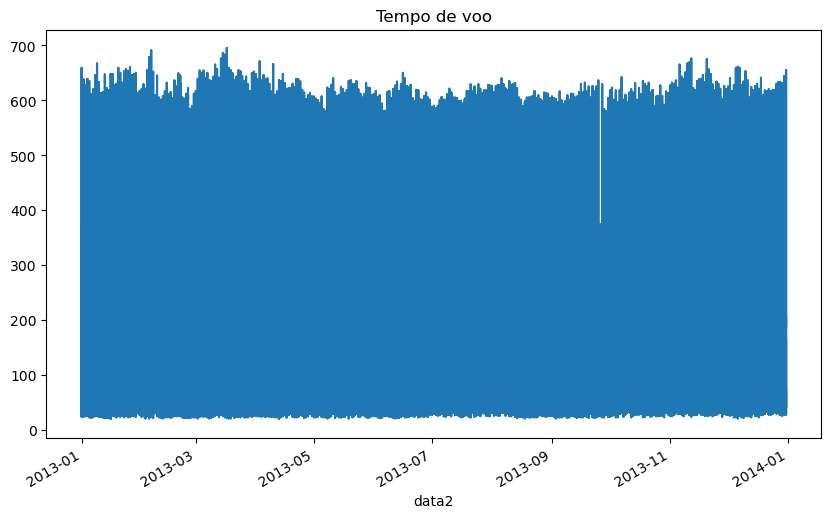

In [64]:
df_ts['air_time'].plot(figsize=(10,6),title='Tempo de voo');

O que tem de errado no gráfico acima?

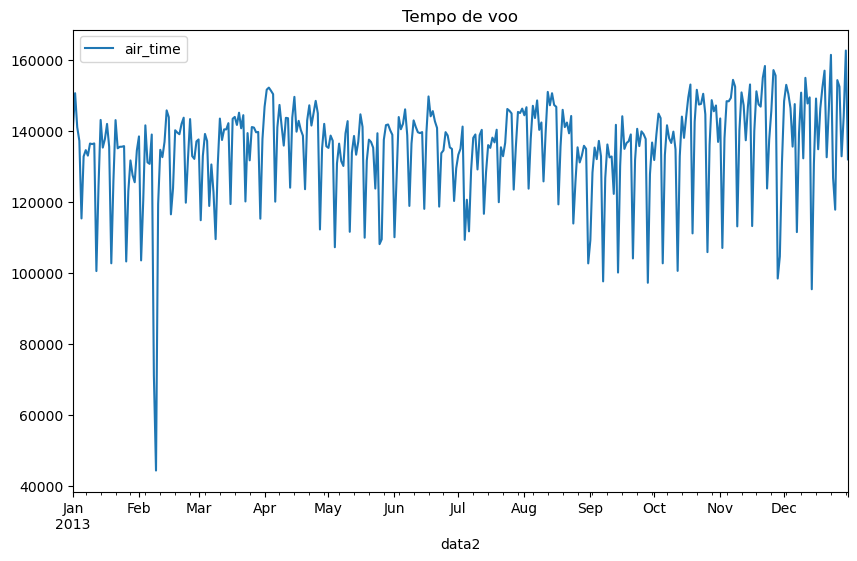

In [65]:
tmp = df.groupby("data2")["air_time"].sum().reset_index()
tmp = tmp.set_index("data2")
tmp.plot(figsize=(10,6),title='Tempo de voo');

In [66]:
tmp

,air_time
data2,
2013-01-01,140981.0
2013-01-02,150520.0
2013-01-03,140934.0
2013-01-04,137106.0
2013-01-05,115288.0
...,...
2013-12-27,152361.0
2013-12-28,132770.0
2013-12-29,144085.0


In [67]:
tmp.resample(rule='W').mean()[:10]
#https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases

,air_time
data2,
2013-01-06,136258.500000
2013-01-13,128759.142857
2013-01-20,131678.285714
2013-01-27,130095.571429
2013-02-03,125867.285714
2013-02-10,110987.428571
2013-02-17,133379.571429
2013-02-24,136525.428571
2013-03-03,132895.000000
